In [34]:
GRID_SIZE = 10

def parameter_list_init():
    param_list = []
    for a in range((GRID_SIZE)):
        eta_plus = .5 + a/GRID_SIZE/2
        eta_minus = .5 - a/GRID_SIZE/2
        for b in range((GRID_SIZE)):
            lambda_plus = 1 + b/GRID_SIZE
            lambda_minus = 1 - b/GRID_SIZE

            param_list.append([eta_plus, eta_minus, lambda_plus, lambda_minus])

    return param_list

params = parameter_list_init()
print(params[95])

[0.95, 0.04999999999999999, 1.5, 0.5]


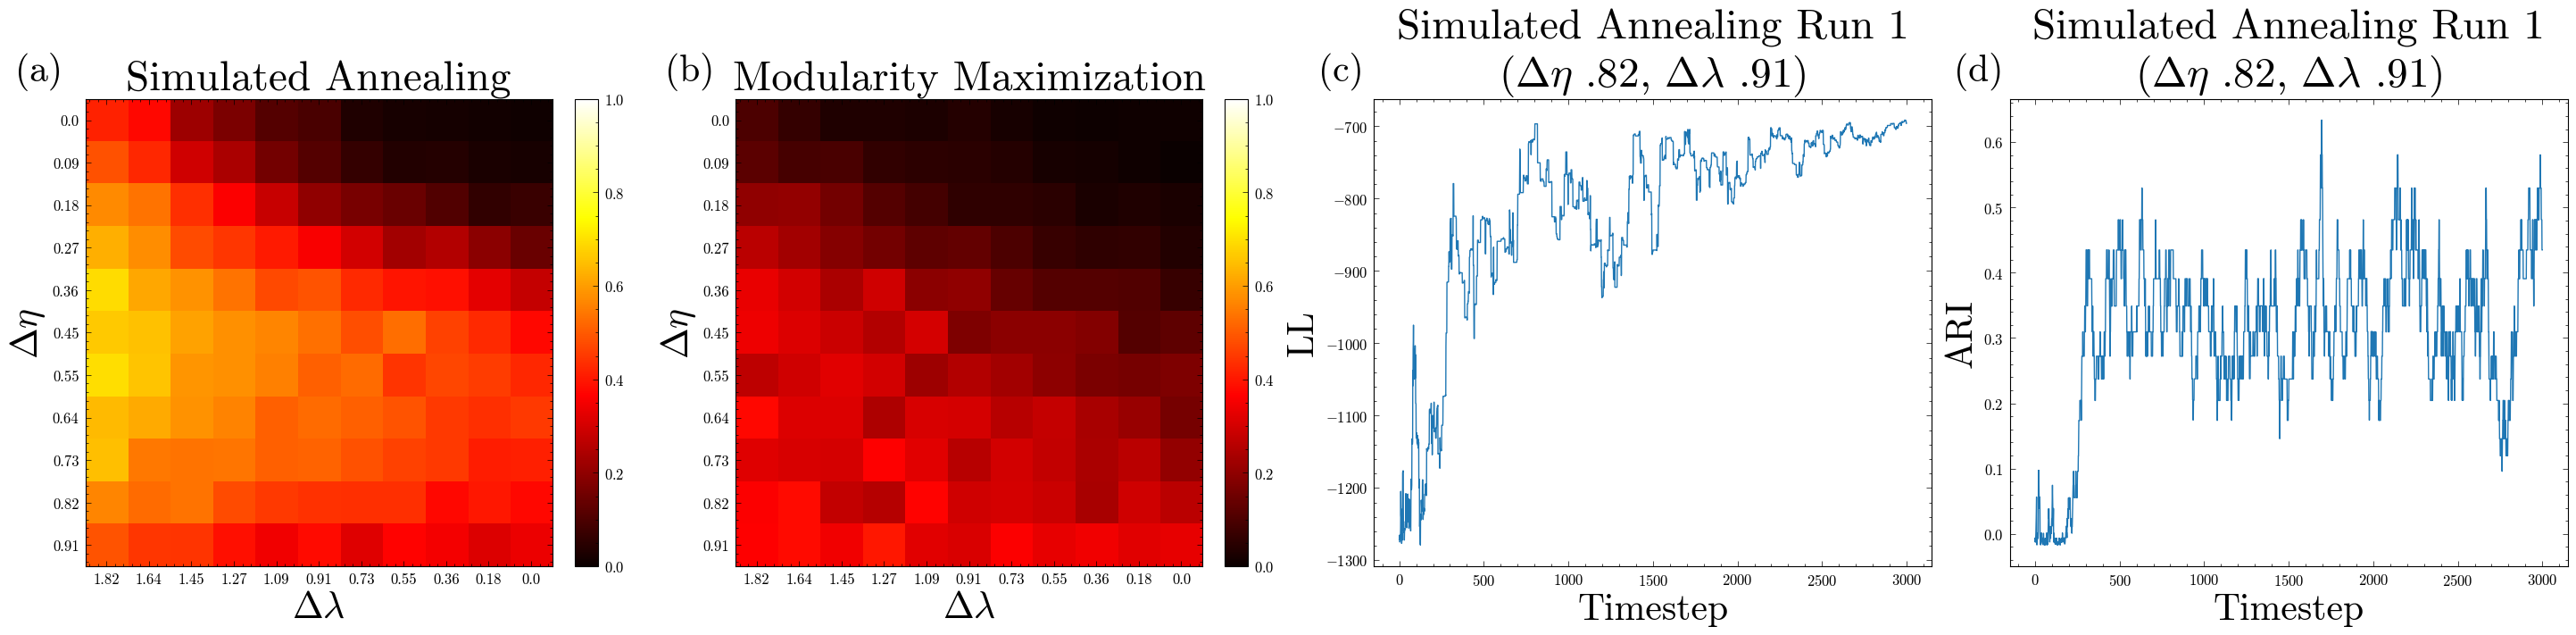

In [ ]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

import numpy as np
import src.poisson_hypergraph as poisson_hypergraph
import xgi
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm

path = os.path.abspath("computermodernstyle.mplstyle")
plt.style.use(path)
plt.rcParams['axes.titlesize'] = 34
# Optional: Set global font size for all axis labels
plt.rcParams['axes.labelsize'] = 30
def make_plot(NMIs_end, title_end, NMIs_best, title_best, grain, ticks_2D, LLs, ARIs):
    step = int(grain/10)

    x_ticks = []
    y_ticks = []

    for i in range(len(ticks_2D)):
        vals = ticks_2D[i][0][:2]
        y_ticks.append(round(float(vals[0]) - float(vals[1]),2))
    
    for i in range(len(ticks_2D)):
        vals = ticks_2D[0][i][2:]
        x_ticks.append(round(float(vals[0]) - float(vals[1]),2))

    # x_ticks.reverse()

    figs,axs = plt.subplots(1,4, figsize=(29,7), constrained_layout=True)
    cmap = cm['hot']
    cmap.set_bad('black',1.)
    img1 = axs[1].imshow(NMIs_end, cmap=cmap, interpolation='nearest', origin = "lower", vmin=0, vmax=1)
    axs[1].set_xticks(list(range(0, grain - 1, step)))
    axs[1].set_yticks(list(range(0, grain - 1, step)))
    axs[1].set_xticklabels(x_ticks)
    axs[1].set_yticklabels(y_ticks)
    axs[1].set_xlabel("$\Delta\lambda$")
    axs[1].set_ylabel("$\Delta\eta$")
    axs[1].set_title(title_end)

    cmap = cm['hot']
    cmap.set_bad('black',1.)
    img2 = axs[0].imshow(NMIs_best, cmap=cmap, interpolation='nearest', origin = "lower", vmin=0, vmax=1)
    axs[0].set_xticks(list(range(0, grain - 1, step)))
    axs[0].set_yticks(list(range(0, grain - 1, step)))
    axs[0].set_xticklabels(x_ticks)
    axs[0].set_yticklabels(y_ticks)
    axs[0].set_xlabel("$\Delta\lambda$")
    axs[0].set_ylabel("$\Delta\eta$")
    axs[0].set_title(title_best)


    for LL_list in LLs[-1:]:
        axs[2].plot(LL_list)

    axs[2].set_title("Simulated Annealing\n($\Delta\eta$ .82, $\Delta\lambda$ .91)")
    axs[2].set_xlabel("Timestep")
    axs[2].set_ylabel("LL")
    
    for ARI_list in ARIs[-1:]:
        axs[3].plot(ARI_list)

    axs[3].set_title("Simulated Annealing\n($\Delta\eta$ .82, $\Delta\lambda$ .91)")
    axs[3].set_xlabel("Timestep")
    axs[3].set_ylabel("ARI")

    axs[0].text(-0.15, 1.1, '(a)', transform=axs[0].transAxes, fontsize=30, fontweight='bold', va='top', ha='left')
    axs[1].text(-0.15, 1.1, '(b)', transform=axs[1].transAxes, fontsize=30, fontweight='bold', va='top', ha='left')
    axs[2].text(-0.1, 1.1, '(c)', transform=axs[2].transAxes, fontsize=30, fontweight='bold', va='top', ha='left')
    axs[3].text(-0.1, 1.1, '(d)', transform=axs[3].transAxes, fontsize=30, fontweight='bold', va='top', ha='left')


    
    

    # figs.subplots_adjust(right=0.85)
    # figs.suptitle("new greedy first old normal")
    # cbar_ax = figs.add_axes([0.9, 0.15, 0.05, 0.7])
    # figs.colorbar(img1, ax=axs, shrink=1, pad=.01, location="left")
    figs.colorbar(img2, fraction=.046, pad=.04)
    figs.colorbar(img1, fraction=.046, pad=.04)

    # plt.tight_layout()



    
    plt.show()


import csv
import math

GRID_SIZE = 11
def generate_LL_NMI_list(filename):
    LLs = [0] * GRID_SIZE*GRID_SIZE 
    NMIs = [0] * GRID_SIZE*GRID_SIZE
    params = [0] * GRID_SIZE*GRID_SIZE
    
    with open(filename, 'r', newline="") as f:
        reader = csv.reader(f)

        for row in reader:
            index = int(row[0])*-1
            
            NMIs[index] = row[1]
            LLs[index] = row[2]
            params[index] = [row[3],row[4],row[5], row[6]]



    params = params[1:] + params[:1]
    LLs = LLs[1:] + LLs[:1]
    NMIs = NMIs[1:] + NMIs[:1]
        
    return LLs, NMIs, params


# def parameter_list_init():
#     param_list = []
#     for a in range((GRID_SIZE)):
#         eta_plus = .5 + a/GRID_SIZE/2
#         eta_minus = .5 - a/GRID_SIZE/2
#         for b in range((GRID_SIZE)):
#             lambda_plus = 1 + b/GRID_SIZE
#             lambda_minus = 1 - b/GRID_SIZE

#             param_list.append([eta_plus, eta_minus, lambda_plus, lambda_minus])

#     return param_list

# params = parameter_list_init()


LLs, NMIs, params = generate_LL_NMI_list('../modularity_maximization_ari.csv')

params_2D = []
len_sqrt = int(math.sqrt(len(params)))
for i in range(len_sqrt):
    temp = []
    for j in range(len_sqrt):
        temp.append(params[i*len_sqrt + j])
    params_2D.append(temp)

NMIs_2D = []

len_sqrt = int(math.sqrt(len(NMIs)))
for i in range(len_sqrt):
    temp = []
    for j in range(len_sqrt):
        temp.append(NMIs[i*len_sqrt + j])
    NMIs_2D.append(temp)

ARI_1 = np.array(NMIs_2D, dtype=float)


LLs, NMIs, params = generate_LL_NMI_list('../simulated_annealing.csv')

params_2D = []
len_sqrt = int(math.sqrt(len(params)))
for i in range(len_sqrt):
    temp = []
    for j in range(len_sqrt):
        temp.append(params[i*len_sqrt + j])
    params_2D.append(temp)

NMIs_2D = []

len_sqrt = int(math.sqrt(len(NMIs)))
for i in range(len_sqrt):
    temp = []
    for j in range(len_sqrt):
        temp.append(NMIs[i*len_sqrt + j])
    NMIs_2D.append(temp)

ARI_2 = np.array(NMIs_2D, dtype=float)

ARIs = []
LLs = []

with open("../simulated_annealing_full_runs_ari.csv", 'r', newline="") as file:
    reader = csv.reader(file)

    for row in reader:
        row = [float(elt) for elt in row[1:]]
        ARIs.append(row)

with open("../simulated_annealing_full_runs_LL.csv", 'r', newline="") as file:
    reader = csv.reader(file)

    for row in reader:
        row = [float(elt) for elt in row[1:]]
        LLs.append(row)


LLs = LLs[1:]
ARIs = ARIs[1:]
#print(LLs)





make_plot(ARI_1, "Modularity Maximization", ARI_2, "Simulated Annealing", 11, params_2D, LLs, ARIs)



